# 05 — Benchmark sample des transformations de la cible

Objectif de ce notebook :

- tester plusieurs **transformations de la cible** :
  - logarithmique (`log1p`)
  - racine carrée (`sqrt`)
  - Box-Cox
  - Yeo-Johnson
- comparer ces transformations sur un **benchmark sample uniquement**
- tester plusieurs modèles, dans la continuité du projet

**Important :**
- les métriques sont calculées sur l'échelle **d'origine** de la cible (`Yield_tons_per_hectare`)
- ce notebook est un **test exploratoire contrôlé**
- il ne remplace pas automatiquement le modèle final du projet

In [1]:
from pathlib import Path
import sys
import json

ROOT = Path.cwd().resolve().parent
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PolynomialFeatures, FunctionTransformer, PowerTransformer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge
from xgboost import XGBRegressor
from catboost import CatBoostRegressor

from project_paths import PROCESSED_DIR

import mlflow
import mlflow.sklearn

SEED = 42
SAMPLE_SIZE = 100_000

MLFLOW_DB_PATH = ROOT / "mlflow.db"
mlflow.set_tracking_uri(f"sqlite:///{MLFLOW_DB_PATH.as_posix()}")
mlflow.set_experiment("projet-12-target-transform-sample")

OUT_DIR = ROOT / "outputs"
OUT_DIR.mkdir(parents=True, exist_ok=True)

print("ROOT:", ROOT)
print("PROCESSED_DIR:", PROCESSED_DIR)
print("MLflow URI:", mlflow.get_tracking_uri())

2026/03/31 14:17:08 INFO mlflow.tracking.fluent: Experiment with name 'projet-12-target-transform-sample' does not exist. Creating a new experiment.


ROOT: C:\Users\thoma\Documents\Openclassroom\Projet-12
PROCESSED_DIR: C:\Users\thoma\Documents\Openclassroom\Projet-12\data\processed
MLflow URI: sqlite:///C:/Users/thoma/Documents/Openclassroom/Projet-12/mlflow.db


In [2]:
crop_aux_enriched = pd.read_csv(PROCESSED_DIR / "crop_aux_enriched.csv")

target_col = "Yield_tons_per_hectare"

print("crop_aux_enriched :", crop_aux_enriched.shape)
display(crop_aux_enriched.head())

assert (crop_aux_enriched[target_col] >= 0).all(), "La cible contient encore des valeurs négatives."

sample_df = crop_aux_enriched.sample(
    n=min(SAMPLE_SIZE, len(crop_aux_enriched)),
    random_state=SEED
).copy()

print("sample_df :", sample_df.shape)
display(sample_df[[target_col]].describe().T)

crop_aux_enriched : (999769, 59)


,Region,Soil_Type,Crop,Rainfall_mm,Temperature_Celsius,Fertilizer_Used,Irrigation_Used,Weather_Condition,Days_to_Harvest,Yield_tons_per_hectare,...,irrigation_profile_score,soil_matches_crop_modal_profile,region_matches_crop_modal_profile,weather_matches_crop_modal_profile,fertilizer_matches_crop_modal_profile,irrigation_matches_crop_modal_profile,mean_binary_profile_score,mean_categorical_profile_score,mean_context_profile_score,mean_modal_match_score
0,West,Sandy,Cotton,897.077239,27.676966,False,True,Cloudy,122,6.555816,...,0.499622,1,0,0,0,0,0.499451,0.249712,0.349607,0.2
1,South,Clay,Rice,992.673282,18.026142,True,True,Rainy,140,8.527341,...,0.496504,1,0,0,1,0,0.498501,0.250467,0.349680,0.4
2,North,Loam,Barley,147.998025,29.794042,False,False,Sunny,106,1.127443,...,0.500345,1,1,0,1,1,0.500468,0.250227,0.350324,0.8
3,North,Sandy,Soybean,986.866331,16.644190,False,True,Rainy,146,6.517573,...,0.500881,0,0,0,1,1,0.500499,0.249284,0.349770,0.4
4,South,Silt,Wheat,730.379174,31.620687,True,True,Cloudy,110,7.248251,...,0.500906,0,0,1,1,1,0.501080,0.250832,0.350931,0.6


sample_df : (100000, 59)


,count,mean,std,min,25%,50%,75%,max
Yield_tons_per_hectare,100000.0,4.649495,1.694494,0.002143,3.420518,4.650238,5.876204,9.727004


In [3]:
crop_enriched_features = [
    "Crop",
    "Rainfall_mm",
    "Temperature_Celsius",
    "Fertilizer_Used",
    "Irrigation_Used",
    "ext_mean_temp_by_crop",
    "ext_mean_rainfall_by_crop",
    "ext_mean_pesticides_by_crop",
    "ext_n_obs_by_crop",
    "rainfall_gap_vs_crop_profile",
    "temp_gap_vs_crop_profile",
]

X_sample = sample_df[crop_enriched_features].copy()
y_sample = sample_df[target_col].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X_sample,
    y_sample,
    test_size=0.2,
    random_state=SEED,
)

print("X_train :", X_train.shape)
print("X_test  :", X_test.shape)
print("y_train min/max :", y_train.min(), y_train.max())

X_train : (80000, 11)
X_test  : (20000, 11)
y_train min/max : 0.0054631870857904 9.549031544620227


In [4]:
def split_feature_types(df: pd.DataFrame):
    bool_features = df.select_dtypes(include="bool").columns.tolist()
    numeric_features = df.select_dtypes(include=np.number).columns.tolist()
    numeric_features = numeric_features + [c for c in bool_features if c not in numeric_features]
    categorical_features = [c for c in df.columns if c not in numeric_features]
    return numeric_features, categorical_features


def build_preprocessor(numeric_features, categorical_features):
    numeric_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])

    categorical_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ])

    return ColumnTransformer([
        ("num", numeric_pipeline, numeric_features),
        ("cat", categorical_pipeline, categorical_features),
    ])


def make_pipeline(model, X: pd.DataFrame):
    numeric_features, categorical_features = split_feature_types(X)
    preprocessor = build_preprocessor(numeric_features, categorical_features)
    return Pipeline([
        ("preprocessor", preprocessor),
        ("model", model),
    ])


def make_interaction_pipeline(model, X: pd.DataFrame):
    numeric_features, categorical_features = split_feature_types(X)
    preprocessor = build_preprocessor(numeric_features, categorical_features)

    return Pipeline([
        ("preprocessor", preprocessor),
        ("interactions", PolynomialFeatures(
            degree=2,
            interaction_only=True,
            include_bias=False,
        )),
        ("model", model),
    ])


def evaluate_regression(y_true, y_pred) -> dict:
    return {
        "rmse": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "mae": float(mean_absolute_error(y_true, y_pred)),
        "r2": float(r2_score(y_true, y_pred)),
    }

In [5]:
class BoxCoxShiftedTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, offset: float = 1e-6, standardize: bool = False):
        self.offset = offset
        self.standardize = standardize

    def fit(self, y, *_):
        y_arr = np.asarray(y, dtype=float).reshape(-1, 1)
        self.transformer_ = PowerTransformer(method="box-cox", standardize=self.standardize)
        self.transformer_.fit(y_arr + self.offset)
        return self

    def transform(self, y):
        y_arr = np.asarray(y, dtype=float).reshape(-1, 1)
        return self.transformer_.transform(y_arr + self.offset)

    def inverse_transform(self, y):
        y_arr = np.asarray(y, dtype=float).reshape(-1, 1)
        return self.transformer_.inverse_transform(y_arr) - self.offset


class YeoJohnsonTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, standardize: bool = False):
        self.standardize = standardize

    def fit(self, y, *_):
        y_arr = np.asarray(y, dtype=float).reshape(-1, 1)
        self.transformer_ = PowerTransformer(method="yeo-johnson", standardize=self.standardize)
        self.transformer_.fit(y_arr)
        return self

    def transform(self, y):
        y_arr = np.asarray(y, dtype=float).reshape(-1, 1)
        return self.transformer_.transform(y_arr)

    def inverse_transform(self, y):
        y_arr = np.asarray(y, dtype=float).reshape(-1, 1)
        return self.transformer_.inverse_transform(y_arr)

In [6]:
target_transformers = {
    "none": None,
    "log1p": FunctionTransformer(
        func=np.log1p,
        inverse_func=np.expm1,
        validate=False,
        feature_names_out="one-to-one",
    ),
    "sqrt": FunctionTransformer(
        func=np.sqrt,
        inverse_func=np.square,
        validate=False,
        feature_names_out="one-to-one",
    ),
    "boxcox": BoxCoxShiftedTransformer(offset=1e-6, standardize=False),
    "yeo_johnson": YeoJohnsonTransformer(standardize=False),
}

transform_preview = pd.DataFrame({
    "y_original": y_train.to_numpy()[:10],
})

for name, transformer in target_transformers.items():
    if name == "none":
        transform_preview[name] = transform_preview["y_original"]
    else:
        transformer.fit(y_train)
        transform_preview[name] = transformer.transform(y_train.to_numpy()[:10]).ravel()

display(transform_preview)

,y_original,none,log1p,sqrt,boxcox,yeo_johnson
0,5.553087,5.553087,1.879936,2.356499,4.146637,5.026862
1,4.322781,4.322781,1.671996,2.079130,3.074722,3.964360
2,7.808625,7.808625,2.175731,2.794392,6.061497,6.934195
3,6.243118,6.243118,1.980052,2.498623,4.738556,5.615391
4,2.845140,2.845140,1.346810,1.686754,1.750576,2.660451
5,3.569104,3.569104,1.519317,1.889207,2.405286,3.303649
6,2.480453,2.480453,1.247162,1.574945,1.415471,2.332752
7,8.196865,8.196865,2.218863,2.863017,6.385849,7.258129
8,6.514541,6.514541,2.016840,2.552360,4.969804,5.845599
9,4.997909,4.997909,1.791411,2.235600,3.665787,4.549648


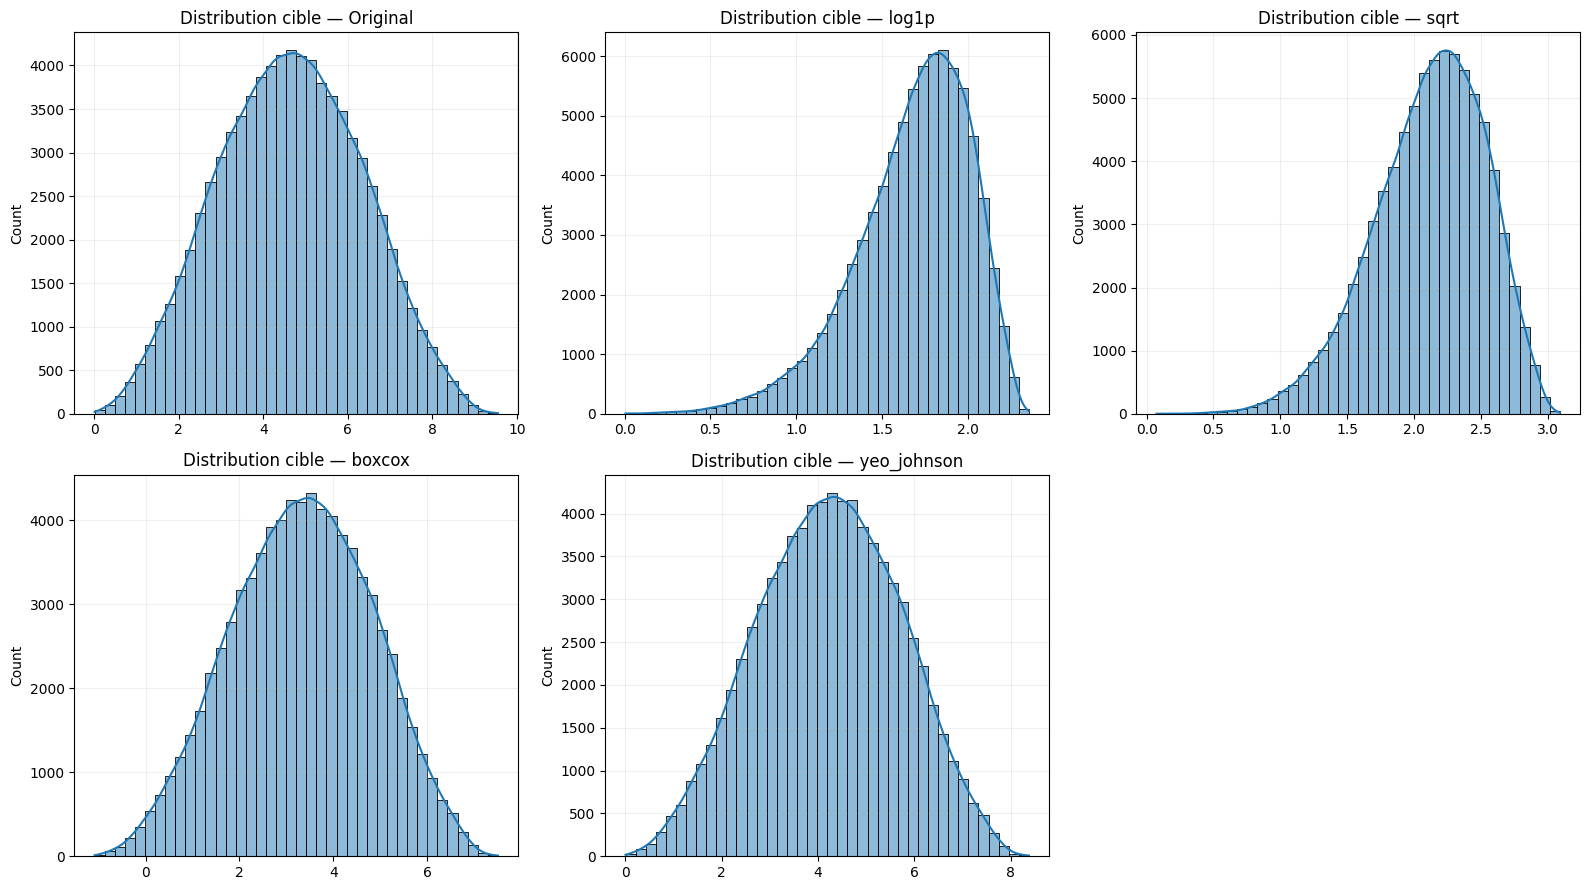

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.ravel()

plot_data = [
    ("Original", y_train.to_numpy()),
    ("log1p", np.log1p(y_train.to_numpy())),
    ("sqrt", np.sqrt(y_train.to_numpy())),
]

# Box-Cox
boxcox_transformer = BoxCoxShiftedTransformer(offset=1e-6, standardize=False)
boxcox_transformer.fit(y_train)
plot_data.append(("boxcox", boxcox_transformer.transform(y_train).ravel()))

# Yeo-Johnson
yeojohnson_transformer = YeoJohnsonTransformer(standardize=False)
yeojohnson_transformer.fit(y_train)
plot_data.append(("yeo_johnson", yeojohnson_transformer.transform(y_train).ravel()))

for ax, (name, values) in zip(axes, plot_data):
    sns.histplot(values, bins=40, kde=True, ax=ax)
    ax.set_title(f"Distribution cible — {name}")
    ax.grid(alpha=0.2)

# dernière case vide
if len(plot_data) < len(axes):
    axes[-1].axis("off")

plt.tight_layout()
plt.show()

In [8]:
base_models = {
    "linear_regression": LinearRegression(),
    "ridge": Ridge(alpha=0.1),
    "catboost": CatBoostRegressor(
        iterations=250,
        depth=6,
        learning_rate=0.05,
        loss_function="RMSE",
        verbose=0,
        random_seed=SEED,
        allow_writing_files=False,
        thread_count=1,
    ),
    "xgboost": XGBRegressor(
        n_estimators=250,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=SEED,
        n_jobs=1,
    ),
}

interaction_models = {
    "ridge_interactions": Ridge(alpha=1.0),
}

In [9]:
def fit_predict_with_optional_target_transform(
    model_name: str,
    model,
    target_transform_name: str,
    transformer,
    X_train: pd.DataFrame,
    X_test: pd.DataFrame,
    y_train: pd.Series,
):
    if model_name == "ridge_interactions":
        regressor = make_interaction_pipeline(model, X_train)
    else:
        regressor = make_pipeline(model, X_train)

    if target_transform_name == "none":
        final_model = regressor
    else:
        final_model = TransformedTargetRegressor(
            regressor=regressor,
            transformer=transformer,
            check_inverse=False,
        )

    final_model.fit(X_train, y_train)
    preds = final_model.predict(X_test)
    return final_model, preds


def benchmark_target_transforms(
    X_train: pd.DataFrame,
    X_test: pd.DataFrame,
    y_train: pd.Series,
    y_test: pd.Series,
    models_dict: dict,
    transformers_dict: dict,
    benchmark_name: str,
):
    rows = []

    for model_name, model in models_dict.items():
        for transform_name, transformer in transformers_dict.items():
            final_model, preds = fit_predict_with_optional_target_transform(
                model_name=model_name,
                model=model,
                target_transform_name=transform_name,
                transformer=transformer,
                X_train=X_train,
                X_test=X_test,
                y_train=y_train,
            )

            metrics = evaluate_regression(y_test, preds)

            rows.append({
                "benchmark": benchmark_name,
                "model": model_name,
                "target_transform": transform_name,
                **metrics,
            })

            with mlflow.start_run(run_name=f"{benchmark_name}__{model_name}__{transform_name}"):
                mlflow.set_tags({
                    "project": "Projet-12",
                    "notebook": "05_target_transform_benchmark_sample",
                    "stage": "sample_target_transform_benchmark",
                    "benchmark": benchmark_name,
                    "model_name": model_name,
                    "target_transform": transform_name,
                })
                mlflow.log_param("benchmark", benchmark_name)
                mlflow.log_param("model_name", model_name)
                mlflow.log_param("target_transform", transform_name)
                mlflow.log_param("n_train_rows", len(X_train))
                mlflow.log_param("n_test_rows", len(X_test))
                mlflow.log_param("feature_names", ",".join(X_train.columns.tolist()))
                mlflow.log_metrics(metrics)

    return pd.DataFrame(rows).sort_values(["rmse", "mae"]).reset_index(drop=True)

In [10]:
base_benchmark_results = benchmark_target_transforms(
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    y_test=y_test,
    models_dict=base_models,
    transformers_dict=target_transformers,
    benchmark_name="sample_crop_enriched",
)

display(base_benchmark_results)

,benchmark,model,target_transform,rmse,mae,r2
0,sample_crop_enriched,ridge,none,0.501084,0.399570,0.912154
1,sample_crop_enriched,linear_regression,none,0.501084,0.399570,0.912154
2,sample_crop_enriched,ridge,yeo_johnson,0.501485,0.399909,0.912014
3,sample_crop_enriched,linear_regression,yeo_johnson,0.501485,0.399909,0.912014
4,sample_crop_enriched,catboost,boxcox,0.501689,0.400005,0.911942
5,sample_crop_enriched,catboost,none,0.501713,0.400044,0.911934
6,sample_crop_enriched,catboost,yeo_johnson,0.501763,0.400079,0.911916
7,sample_crop_enriched,ridge,boxcox,0.501864,0.400228,0.911881
8,sample_crop_enriched,linear_regression,boxcox,0.501864,0.400228,0.911881
9,sample_crop_enriched,catboost,log1p,0.502280,0.400566,0.911734


In [11]:
interaction_benchmark_results = benchmark_target_transforms(
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    y_test=y_test,
    models_dict=interaction_models,
    transformers_dict=target_transformers,
    benchmark_name="sample_crop_enriched_interactions",
)

display(interaction_benchmark_results)

,benchmark,model,target_transform,rmse,mae,r2
0,sample_crop_enriched_interactions,ridge_interactions,none,0.501145,0.399653,0.912133
1,sample_crop_enriched_interactions,ridge_interactions,yeo_johnson,0.501170,0.399682,0.912124
2,sample_crop_enriched_interactions,ridge_interactions,boxcox,0.501218,0.399731,0.912108
3,sample_crop_enriched_interactions,ridge_interactions,sqrt,0.506425,0.403973,0.910272
4,sample_crop_enriched_interactions,ridge_interactions,log1p,0.516199,0.411687,0.906775


In [12]:
all_results = pd.concat(
    [base_benchmark_results, interaction_benchmark_results],
    ignore_index=True,
).sort_values(["rmse", "mae"]).reset_index(drop=True)

display(all_results)

,benchmark,model,target_transform,rmse,mae,r2
0,sample_crop_enriched,ridge,none,0.501084,0.399570,0.912154
1,sample_crop_enriched,linear_regression,none,0.501084,0.399570,0.912154
2,sample_crop_enriched_interactions,ridge_interactions,none,0.501145,0.399653,0.912133
3,sample_crop_enriched_interactions,ridge_interactions,yeo_johnson,0.501170,0.399682,0.912124
4,sample_crop_enriched_interactions,ridge_interactions,boxcox,0.501218,0.399731,0.912108
5,sample_crop_enriched,ridge,yeo_johnson,0.501485,0.399909,0.912014
6,sample_crop_enriched,linear_regression,yeo_johnson,0.501485,0.399909,0.912014
7,sample_crop_enriched,catboost,boxcox,0.501689,0.400005,0.911942
8,sample_crop_enriched,catboost,none,0.501713,0.400044,0.911934
9,sample_crop_enriched,catboost,yeo_johnson,0.501763,0.400079,0.911916


In [13]:
summary_by_transform = (
    all_results.groupby("target_transform")[["rmse", "mae", "r2"]]
    .agg(["mean", "min", "max"])
)

display(summary_by_transform)

rmse                           mae                      \
                      mean       min       max      mean       min       max   
target_transform                                                               
boxcox            0.502059  0.501218  0.503660  0.400312  0.399731  0.401368   
log1p             0.547893  0.502280  0.608081  0.434257  0.400566  0.478343   
none              0.501767  0.501084  0.503809  0.400061  0.399570  0.401467   
sqrt              0.517080  0.502344  0.536147  0.412335  0.400558  0.427553   
yeo_johnson       0.501926  0.501170  0.503728  0.400183  0.399682  0.401334   

                        r2                      
                      mean       min       max  
target_transform                                
boxcox            0.911812  0.911249  0.912108  
log1p             0.894123  0.870634  0.911734  
none              0.911914  0.911196  0.912154  
sqrt              0.906371  0.899430  0.911712  
yeo_johnson       0.911859  0.911225  0.912124

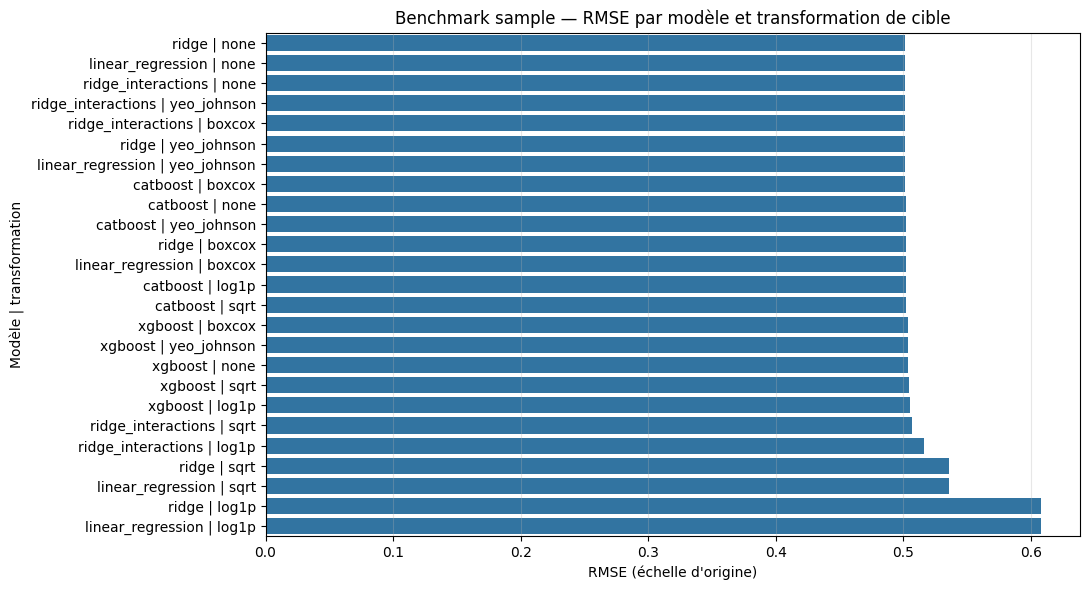

In [14]:
plt.figure(figsize=(11, 6))
sns.barplot(
    data=all_results.sort_values("rmse"),
    x="rmse",
    y=all_results.sort_values("rmse").apply(
        lambda row: f"{row['model']} | {row['target_transform']}",
        axis=1,
    ),
)
plt.title("Benchmark sample — RMSE par modèle et transformation de cible")
plt.xlabel("RMSE (échelle d'origine)")
plt.ylabel("Modèle | transformation")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

In [15]:
best_row = all_results.iloc[0].to_dict()
best_row

{'benchmark': 'sample_crop_enriched',
 'model': 'ridge',
 'target_transform': 'none',
 'rmse': 0.5010838341562119,
 'mae': 0.3995695412962591,
 'r2': 0.9121544394134077}

In [16]:
best_model_name = best_row["model"]
best_transform_name = best_row["target_transform"]

if best_model_name == "ridge_interactions":
    best_model = interaction_models[best_model_name]
else:
    best_model = base_models[best_model_name]

best_transformer = target_transformers[best_transform_name]

best_pipeline, best_preds = fit_predict_with_optional_target_transform(
    model_name=best_model_name,
    model=best_model,
    target_transform_name=best_transform_name,
    transformer=best_transformer,
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
)

best_comparison_df = pd.DataFrame({
    "y_true": y_test.to_numpy(),
    "y_pred": best_preds,
    "residual": y_test.to_numpy() - best_preds,
})

display(best_comparison_df.head())
display(best_comparison_df.describe().T)

,y_true,y_pred,residual
0,2.427354,2.205381,0.221972
1,4.476046,4.495154,-0.019108
2,2.397504,2.640925,-0.243420
3,4.440527,4.514564,-0.074037
4,4.608234,3.545498,1.062736


,count,mean,std,min,25%,50%,75%,max
y_true,20000.0,4.654325,1.690680,0.002143,3.432413,4.652015,5.886437,9.727004
y_pred,20000.0,4.657120,1.621890,0.810799,3.464150,4.653989,5.873088,8.490505
residual,20000.0,-0.002795,0.501089,-1.878625,-0.337404,-0.002870,0.334766,2.027673


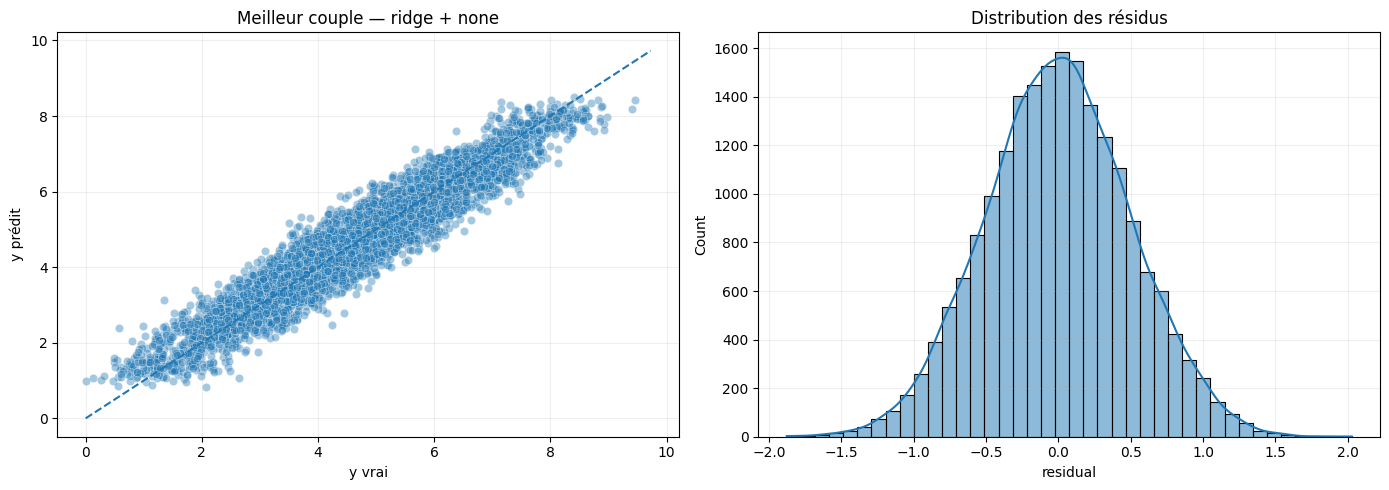

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(
    data=best_comparison_df.sample(n=min(5000, len(best_comparison_df)), random_state=SEED),
    x="y_true",
    y="y_pred",
    alpha=0.4,
    ax=axes[0],
)
min_v = min(best_comparison_df["y_true"].min(), best_comparison_df["y_pred"].min())
max_v = max(best_comparison_df["y_true"].max(), best_comparison_df["y_pred"].max())
axes[0].plot([min_v, max_v], [min_v, max_v], linestyle="--")
axes[0].set_title(f"Meilleur couple — {best_model_name} + {best_transform_name}")
axes[0].set_xlabel("y vrai")
axes[0].set_ylabel("y prédit")
axes[0].grid(alpha=0.2)

sns.histplot(best_comparison_df["residual"], bins=40, kde=True, ax=axes[1])
axes[1].set_title("Distribution des résidus")
axes[1].grid(alpha=0.2)

plt.tight_layout()
plt.show()

In [18]:
results_path = OUT_DIR / "target_transform_sample_benchmark_results.csv"
summary_path = OUT_DIR / "target_transform_sample_benchmark_summary.csv"

all_results.to_csv(results_path, index=False)
summary_by_transform.to_csv(summary_path)

print("Résultats détaillés sauvegardés :", results_path)
print("Résumé sauvegardé :", summary_path)

Résultats détaillés sauvegardés : C:\Users\thoma\Documents\Openclassroom\Projet-12\outputs\target_transform_sample_benchmark_results.csv
Résumé sauvegardé : C:\Users\thoma\Documents\Openclassroom\Projet-12\outputs\target_transform_sample_benchmark_summary.csv


## Lecture attendue

À la fin de ce notebook, il faudra répondre à trois questions :

1. **Une transformation de la cible améliore-t-elle réellement les métriques ?**
2. **Le classement des modèles change-t-il ?**
3. **Le gain éventuel justifie-t-il la complexité supplémentaire** (transformation + inverse transformation + interprétation) ?

Le critère principal à regarder est le **RMSE sur l'échelle d'origine**.